In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/monthly_processed_data/data-2025-01.parquet")
STATIONS_PATH = Path("data/stations_present_in_all_months.csv")

stable_stations = pd.read_csv(STATIONS_PATH)["station_name"].drop_duplicates()

df_unfiltered = pd.read_parquet(
    DATA_PATH,
    engine="pyarrow",
    filters=[("train_type", "in", ["ICE", "IC"])],
)

outside_panel = (
    df_unfiltered.loc[
        ~df_unfiltered["station_name"].isin(stable_stations),
        "station_name",
    ]
    .value_counts()
    .rename_axis("station_name")
    .to_frame("ICE/IC stop records")
)

df = df_unfiltered.loc[
    df_unfiltered["station_name"].isin(stable_stations)
].copy()

coverage_summary = pd.DataFrame({
    "Value": [
        stable_stations.nunique(),
        df_unfiltered["station_name"].nunique(),
        len(df_unfiltered),
        len(df),
        len(df_unfiltered) - len(df),
        df["station_name"].nunique(),
    ]
}, index=[
    "Stations in stable panel",
    "Stations with ICE/IC records before filtering",
    "ICE/IC records before filtering",
    "ICE/IC records after filtering",
    "Records excluded by station filter",
    "Stable-panel stations with ICE/IC records",
])

display(coverage_summary)
display(outside_panel)
display(df.head())

,Value
Stations in stable panel,105
Stations with ICE/IC records before filtering,99
ICE/IC records before filtering,195426
ICE/IC records after filtering,195153
Records excluded by station filter,273
Stable-panel stations with ICE/IC records,97


,ICE/IC stop records
station_name,
Weimar,227
Berlin Ostkreuz,46


,station_name,xml_station_name,eva,train_number,line_number,final_destination_station,delay_in_min,time,arrival_is_canceled,departure_is_canceled,...,is_additional_stop,is_replacement_train,replaced_train_number,train_line_ride_id,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time,id
0,München Hbf,München Hbf,08000261,618,NaN,Kiel Hbf,0,2025-01-01 00:00:00,False,False,...,False,False,NaN,2686007473625185344,1,NaT,NaT,2025-01-01 00:00:00,2025-01-01 00:00:00,2686007473625185344-2501010000-1
1,Köln Hbf,Köln Hbf,08000207,619,NaN,München Hbf,6,2025-01-01 00:01:00,False,False,...,False,False,NaN,7474414276230536927,14,2024-12-31 23:49:00,2024-12-31 23:51:00,2024-12-31 23:55:00,2025-01-01 00:01:00,7474414276230536927-2412311838-14
2,Berlin Südkreuz,Berlin Südkreuz,08011113,805,NaN,Berlin Südkreuz,-1,2025-01-01 00:01:00,False,False,...,False,False,NaN,5554857220674495144,9,2025-01-01 00:02:00,2025-01-01 00:01:00,NaT,NaT,5554857220674495144-2412312134-9
3,Mannheim Hbf,Mannheim Hbf,08000244,775,NaN,Karlsruhe Hbf,2,2025-01-01 00:01:00,False,False,...,False,False,NaN,5181720942697741094,8,2024-12-31 23:56:00,2024-12-31 23:57:00,2024-12-31 23:59:00,2025-01-01 00:01:00,5181720942697741094-2412311833-8
4,Ulm Hbf,Ulm Hbf,08000170,1060,NaN,Stuttgart Hbf,0,2025-01-01 00:01:00,False,False,...,False,False,NaN,4747644076881825118,4,2024-12-31 23:59:00,2024-12-31 23:59:00,2025-01-01 00:01:00,2025-01-01 00:01:00,4747644076881825118-2412312245-4


### Dataset scope

The January 2025 ICE/IC analysis is restricted to the 105 stations
present throughout the complete dataset. The resulting subset contains
195,153 stop records from 97 stations. The remaining stable-panel
stations have no ICE/IC records during this month.

A total of 273 ICE/IC stop records from Weimar and Berlin Ostkreuz were
excluded because those stations are not present throughout the full
observation period. This improves comparability across months, but the
data still represent a station panel rather than complete nationwide
journeys.

In [2]:
quality = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing percent": df.isna().mean().mul(100),
}).sort_values("Missing percent", ascending=False)

display(quality.round(2))

print("Exact duplicate rows:", df.duplicated().sum())
print("Repeated stop IDs:", df["id"].duplicated().sum())

,Missing count,Missing percent
line_number,195153,100.00
replaced_train_number,192067,98.42
departure_change_time,19794,10.14
departure_planned_time,19794,10.14
arrival_change_time,19756,10.12
arrival_planned_time,19756,10.12
station_name,0,0.00
is_additional_stop,0,0.00
train_line_station_num,0,0.00
train_line_ride_id,0,0.00


Exact duplicate rows: 0
Repeated stop IDs: 0


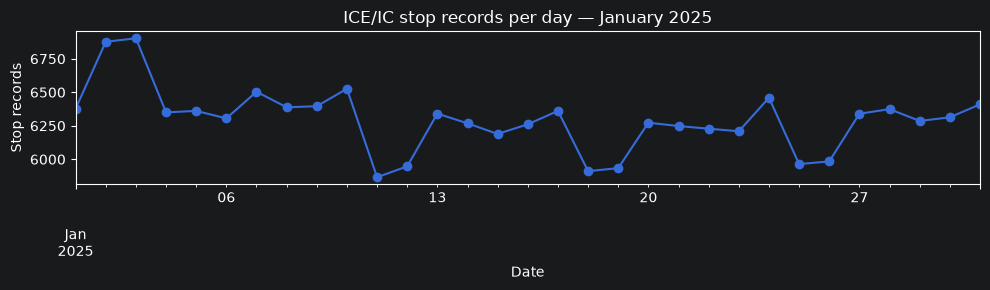

,Stop records
count,31.00
mean,6295.26
std,238.79
min,5866.00
25%,6218.50
50%,6313.00
75%,6382.50
max,6903.00


In [3]:
daily_counts = (
    df.groupby(df["time"].dt.normalize())
      .size()
      .reindex(pd.date_range("2025-01-01", "2025-01-31"), fill_value=0)
)

ax = daily_counts.plot(
    figsize=(10, 3),
    marker="o",
    title="ICE/IC stop records per day — January 2025",
)

ax.set_xlabel("Date")
ax.set_ylabel("Stop records")
plt.tight_layout()
plt.show()

display(daily_counts.describe().round(2).to_frame("Stop records"))

In [4]:
check = df.assign(
    journey_key=df["id"].str.rsplit("-", n=1).str[0]
)

check["planned_event_time"] = (
    check["arrival_planned_time"]
    .fillna(check["departure_planned_time"])
)

journeys = check.groupby("journey_key")["planned_event_time"]

first_observed = check["planned_event_time"].eq(
    journeys.transform("min")
)
last_observed = check["planned_event_time"].eq(
    journeys.transform("max")
)

missing_arrival = check["arrival_planned_time"].isna()
missing_departure = check["departure_planned_time"].isna()

missing_time_checks = pd.DataFrame({
    "Value": [
        missing_arrival.sum(),
        (missing_arrival & ~first_observed).sum(),
        missing_departure.sum(),
        (missing_departure & ~last_observed).sum(),
        (missing_arrival & missing_departure).sum(),
    ]
}, index=[
    "Missing arrivals",
    "Missing arrivals outside first observed stop",
    "Missing departures",
    "Missing departures outside last observed stop",
    "Both timestamps missing",
])

display(missing_time_checks)

,Value
Missing arrivals,19756
Missing arrivals outside first observed stop,0
Missing departures,19794
Missing departures outside last observed stop,0
Both timestamps missing,0


In [5]:
endpoints = (
    check.assign(
        has_origin=missing_arrival,
        has_destination=missing_departure,
    )
    .groupby("journey_key")[["has_origin", "has_destination"]]
    .any()
)

origin = endpoints["has_origin"]
destination = endpoints["has_destination"]

endpoint_summary = pd.DataFrame({
    "Endpoint records present": [
        "Both origin and destination",
        "Origin only",
        "Destination only",
        "Neither endpoint",
    ],
    "Journeys": [
        (origin & destination).sum(),
        (origin & ~destination).sum(),
        (~origin & destination).sum(),
        (~origin & ~destination).sum(),
    ],
})

display(endpoint_summary)

print(f"Missing arrivals:   {missing_arrival.sum():,}")
print(f"Missing departures: {missing_departure.sum():,}")
print(f"Difference:         {missing_arrival.sum() - missing_departure.sum():,}")

,Endpoint records present,Journeys
0,Both origin and destination,15623
1,Origin only,4133
2,Destination only,4171
3,Neither endpoint,119


Missing arrivals:   19,756
Missing departures: 19,794
Difference:         -38


### Why missing arrival and departure counts differ

Missing arrival times are consistent with journey origins, while missing
departure times are consistent with destinations. These counts need not
match because the January 2025 ICE/IC subset is limited to the stable
105-station panel and therefore does not capture both endpoints of every
journey.

| Endpoint records present    | Journeys |
| --------------------------- | -------: |
| Both origin and destination |   15,623 |
| Origin only                 |    4,133 |
| Destination only            |    4,171 |
| Neither endpoint            |      119 |

The difference is therefore **4,133 − 4,171 = −38**, matching the difference
between **19,756 missing arrivals** and **19,794 missing departures**.

The limited station coverage is the main reason for incomplete journeys:
many trains begin or end outside the observed station panel. Month
boundaries may also contribute. The exact cause has not been verified for
every journey. We retain these rows without imputing the missing
timestamps.

In [6]:
stops = check.copy()

destinations = stops.loc[
    stops["arrival_planned_time"].notna()
    & stops["departure_planned_time"].isna()
].copy()

assert destinations["journey_key"].is_unique

destinations["arrival_delay_min"] = (
    destinations["arrival_change_time"]
    - destinations["arrival_planned_time"]
).dt.total_seconds() / 60

destination_summary = pd.DataFrame({
    "Value": [
        stops["journey_key"].nunique(),
        len(destinations),
        stops["journey_key"].nunique() - len(destinations),
        destinations["arrival_is_canceled"].sum(),
        destinations["arrival_is_canceled"].mean() * 100,
    ]
}, index=[
    "Observed journey groups",
    "With a recorded destination",
    "Without a recorded destination",
    "Destination arrivals flagged cancelled",
    "Destination cancellation rate (%)",
])

display(destination_summary.round(2))

,Value
Observed journey groups,24046.00
With a recorded destination,19794.00
Without a recorded destination,4252.00
Destination arrivals flagged cancelled,1269.00
Destination cancellation rate (%),6.41


,Arrival delay (minutes)
count,18525.00
mean,11.78
std,20.87
min,-77.00
50%,4.00
90%,35.00
95%,51.00
99%,96.00
max,322.00


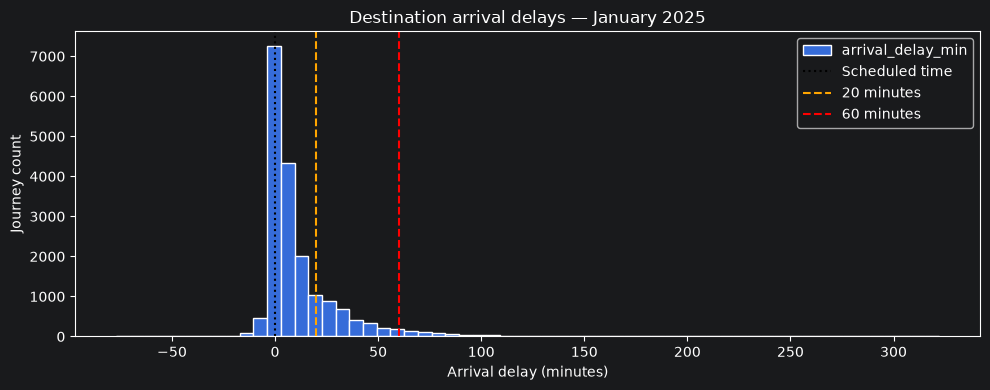

In [7]:
arrival_delays = destinations.loc[
    ~destinations["arrival_is_canceled"],
    "arrival_delay_min",
].dropna()

display(
    arrival_delays.describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
    .round(2)
    .to_frame("Arrival delay (minutes)")
)

ax = arrival_delays.plot.hist(
    bins=60,
    figsize=(10, 4),
    edgecolor="white",
    title="Destination arrival delays — January 2025",
)

ax.axvline(0, color="black", linestyle=":", label="Scheduled time")
ax.axvline(20, color="orange", linestyle="--", label="20 minutes")
ax.axvline(60, color="red", linestyle="--", label="60 minutes")
ax.set_xlabel("Arrival delay (minutes)")
ax.set_ylabel("Journey count")
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
severity = pd.cut(
    arrival_delays,
    bins=[-float("inf"), 20, 60, float("inf")],
    labels=[
        "Below 20 minutes",
        "20–<60 minutes",
        "60+ minutes",
    ],
    right=False,
)

severity_counts = severity.value_counts(sort=False)

severity_summary = pd.DataFrame({
    "Journeys": severity_counts,
    "Percentage": severity_counts
        .div(severity_counts.sum())
        .mul(100)
        .round(2),
})

display(severity_summary)

,Journeys,Percentage
arrival_delay_min,,
Below 20 minutes,14688,79.29
20–<60 minutes,3178,17.16
60+ minutes,659,3.56


### Destination arrival delays and cancellations

Of 27,294 observed journey groups, 24,132 have a destination record.
The remaining 3,162 are excluded from destination-outcome analysis.

Destination arrivals are flagged cancelled in 4,032 cases (16.71%).
This includes possible partial cancellations and does not necessarily
mean the entire train service was cancelled.

Among 20,100 arrivals not flagged cancelled, the median recorded delay
is 11 minutes and the mean is 20.83 minutes. The 95th percentile is
75 minutes, and 8.47% have delays of at least 60 minutes.

These results describe the captured destination records. Changed times
may fall back to planned times during preprocessing, so they are not
always independently observed actual arrivals. Extreme negative and
positive delays require further inspection.

# Candidate Corridors

The two best candidates are:
| Corridor | Journeys | Direction split | Median planned time | Days covered |
|---|---:|---:|---:|---:|
| Berlin Hauptbahnhof ↔ München Hbf | 1,824 | 928 / 896 | 273 min (4h 33m) | 31 |
| Hamburg Hbf ↔ Mannheim Hbf | 1,690 | 872 / 818 | 304 min (5h 04m) | 31 |

Both use stations in the stable 105-station list and have frequent and balanced service in both directions.

In [10]:
CANDIDATE_CORRIDORS = {
    "Berlin–Munich": (
        "Berlin Hauptbahnhof",
        "München Hbf",
    ),
    "Hamburg–Mannheim": (
        "Hamburg Hbf",
        "Mannheim Hbf",
    ),
}


def extract_direction(stops, corridor, origin, destination):
    origin_rows = (
        stops.loc[
            stops["station_name"].eq(origin)
            & stops["departure_planned_time"].notna(),
            [
                "journey_key",
                "departure_planned_time",
                "train_type",
                "train_number",
            ],
        ]
        .rename(columns={
            "departure_planned_time": "origin_departure_planned",
        })
    )

    destination_rows = (
        stops.loc[
            stops["station_name"].eq(destination)
            & stops["arrival_planned_time"].notna(),
            [
                "journey_key",
                "arrival_planned_time",
                "arrival_change_time",
                "arrival_is_canceled",
            ],
        ]
        .rename(columns={
            "arrival_planned_time": "destination_arrival_planned",
            "arrival_change_time": "destination_arrival_changed",
        })
    )

    result = origin_rows.merge(
        destination_rows,
        on="journey_key",
        how="inner",
    )

    result["planned_duration_min"] = (
        result["destination_arrival_planned"]
        - result["origin_departure_planned"]
    ).dt.total_seconds() / 60

    # Require a direct same-train journey lasting 2–6 hours.
    result = result.loc[
        result["planned_duration_min"].between(120, 360)
    ].copy()

    result["arrival_delay_min"] = (
        result["destination_arrival_changed"]
        - result["destination_arrival_planned"]
    ).dt.total_seconds() / 60

    # A cancelled arrival does not have an observed arrival delay.
    result.loc[
        result["arrival_is_canceled"],
        "arrival_delay_min",
    ] = pd.NA

    result["corridor"] = corridor
    result["origin"] = origin
    result["destination"] = destination
    result["departure_date"] = (
        result["origin_departure_planned"].dt.normalize()
    )

    return result.drop_duplicates(
        ["journey_key", "origin", "destination"]
    )


corridor_parts = []

for corridor, (station_a, station_b) in CANDIDATE_CORRIDORS.items():
    corridor_parts.append(
        extract_direction(df.assign(
            journey_key=df["id"].str.rsplit("-", n=1).str[0]
        ), corridor, station_a, station_b)
    )

    corridor_parts.append(
        extract_direction(df.assign(
            journey_key=df["id"].str.rsplit("-", n=1).str[0]
        ), corridor, station_b, station_a)
    )

corridor_data = pd.concat(corridor_parts, ignore_index=True)

print(corridor_data.shape)
display(corridor_data.head())

(3514, 13)


,journey_key,origin_departure_planned,train_type,train_number,destination_arrival_planned,destination_arrival_changed,arrival_is_canceled,planned_duration_min,arrival_delay_min,corridor,origin,destination,departure_date
0,-7202919247926513511-2501010550,2025-01-01 05:59:00,ICE,1001,2025-01-01 10:02:00,2025-01-01 10:01:00,False,243.0,-1.0,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,2025-01-01
1,8049328993498305601-2501010619,2025-01-01 06:28:00,ICE,503,2025-01-01 11:03:00,2025-01-01 11:05:00,False,275.0,2.0,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,2025-01-01
2,-2638916872742442629-2501010652,2025-01-01 07:04:00,ICE,1103,2025-01-01 11:11:00,2025-01-01 11:10:00,False,247.0,-1.0,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,2025-01-01
3,1530853161902385697-2501010734,2025-01-01 07:34:00,ICE,701,2025-01-01 12:42:00,2025-01-01 12:41:00,False,308.0,-1.0,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,2025-01-01
4,-7701132928332510424-2501010811,2025-01-01 08:11:00,ICE,1003,2025-01-01 12:02:00,2025-01-01 12:02:00,False,231.0,0.0,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,2025-01-01


In [11]:
summary_rows = []

for (corridor, origin, destination), group in corridor_data.groupby(
    ["corridor", "origin", "destination"]
):
    completed = group.loc[~group["arrival_is_canceled"]]

    summary_rows.append({
        "Corridor": corridor,
        "Direction": f"{origin} → {destination}",
        "Journeys": len(group),
        "Average per day": len(group) / group["departure_date"].nunique(),
        "Days covered": group["departure_date"].nunique(),
        "Median duration (min)": group["planned_duration_min"].median(),
        "Arrival cancellation rate (%)":
            group["arrival_is_canceled"].mean() * 100,
        "Median arrival delay (min)":
            completed["arrival_delay_min"].median(),
    })

corridor_summary = pd.DataFrame(summary_rows)

display(
    corridor_summary.round(2)
    .sort_values(["Corridor", "Direction"])
    .reset_index(drop=True)
)

,Corridor,Direction,Journeys,Average per day,Days covered,Median duration (min),Arrival cancellation rate (%),Median arrival delay (min)
0,Berlin–Munich,Berlin Hauptbahnhof → München Hbf,928,29.94,31,273.0,4.96,2.0
1,Berlin–Munich,München Hbf → Berlin Hauptbahnhof,896,28.90,31,269.0,2.79,2.0
2,Hamburg–Mannheim,Hamburg Hbf → Mannheim Hbf,872,28.13,31,307.0,3.67,15.0
3,Hamburg–Mannheim,Mannheim Hbf → Hamburg Hbf,818,26.39,31,304.0,2.93,11.0


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

stops = df.assign(
    journey_key=df["id"].str.rsplit("-", n=1).str[0]
)

CANDIDATE_CORRIDORS = {
    "Berlin–Munich": (
        "Berlin Hauptbahnhof",
        "München Hbf",
    ),
    "Hamburg–Mannheim": (
        "Hamburg Hbf",
        "Mannheim Hbf",
    ),
}


def build_corridor_direction(corridor, origin, destination):
    origins = (
        stops.loc[
            stops["station_name"].eq(origin)
            & stops["departure_planned_time"].notna(),
            [
                "journey_key",
                "departure_planned_time",
                "departure_change_time",
                "departure_is_canceled",
                "is_additional_stop",
                "is_replacement_train",
                "train_type",
                "train_number",
            ],
        ]
        .rename(columns={
            "departure_planned_time": "origin_departure_planned",
            "departure_change_time": "origin_departure_changed",
            "departure_is_canceled": "origin_departure_canceled",
            "is_additional_stop": "origin_is_additional",
            "is_replacement_train": "origin_is_replacement",
        })
    )

    destinations = (
        stops.loc[
            stops["station_name"].eq(destination)
            & stops["arrival_planned_time"].notna(),
            [
                "journey_key",
                "arrival_planned_time",
                "arrival_change_time",
                "arrival_is_canceled",
                "is_additional_stop",
                "is_replacement_train",
            ],
        ]
        .rename(columns={
            "arrival_planned_time": "destination_arrival_planned",
            "arrival_change_time": "destination_arrival_changed",
            "arrival_is_canceled": "destination_arrival_canceled",
            "is_additional_stop": "destination_is_additional",
            "is_replacement_train": "destination_is_replacement",
        })
    )

    result = origins.merge(destinations, on="journey_key")

    result["planned_duration_min"] = (
        result["destination_arrival_planned"]
        - result["origin_departure_planned"]
    ).dt.total_seconds() / 60

    result = (
        result.loc[result["planned_duration_min"].between(120, 360)]
        .sort_values([
            "journey_key",
            "origin_departure_planned",
            "destination_arrival_planned",
        ])
        .drop_duplicates("journey_key")
        .copy()
    )

    result["corridor"] = corridor
    result["origin"] = origin
    result["destination"] = destination
    result["departure_date"] = (
        result["origin_departure_planned"].dt.normalize()
    )
    result["departure_hour"] = (
        result["origin_departure_planned"].dt.hour
    )
    result["weekday"] = (
        result["origin_departure_planned"].dt.day_name()
    )

    result["departure_delay_min"] = (
        result["origin_departure_changed"]
        - result["origin_departure_planned"]
    ).dt.total_seconds() / 60

    result["arrival_delay_min"] = (
        result["destination_arrival_changed"]
        - result["destination_arrival_planned"]
    ).dt.total_seconds() / 60

    result["actual_duration_min"] = (
        result["destination_arrival_changed"]
        - result["origin_departure_changed"]
    ).dt.total_seconds() / 60

    result.loc[
        result["origin_departure_canceled"],
        "departure_delay_min",
    ] = np.nan

    result.loc[
        result["destination_arrival_canceled"],
        "arrival_delay_min",
    ] = np.nan

    return result


corridor_parts = []

for corridor, (station_a, station_b) in CANDIDATE_CORRIDORS.items():
    corridor_parts.append(
        build_corridor_direction(corridor, station_a, station_b)
    )
    corridor_parts.append(
        build_corridor_direction(corridor, station_b, station_a)
    )

corridor_segments = pd.concat(corridor_parts, ignore_index=True)

corridor_segments["segment_id"] = (
    corridor_segments["corridor"]
    + "|"
    + corridor_segments["origin"]
    + "|"
    + corridor_segments["destination"]
    + "|"
    + corridor_segments["journey_key"]
)

print(corridor_segments.shape)

(3514, 24)


In [13]:
completed = corridor_segments.loc[
    ~corridor_segments["destination_arrival_canceled"]
].copy()

unusual_rows = []

for corridor, group in completed.groupby("corridor"):
    chronology = group.loc[
        ~group["origin_departure_canceled"]
    ]

    unusual_rows.append({
        "Corridor": corridor,
        "Completed arrivals": len(group),
        "Minimum delay": group["arrival_delay_min"].min(),
        "Maximum delay": group["arrival_delay_min"].max(),
        "Negative delays": group["arrival_delay_min"].lt(0).sum(),
        "At least 10 min early":
            group["arrival_delay_min"].le(-10).sum(),
        "Exactly zero": group["arrival_delay_min"].eq(0).sum(),
        "At least 120 min late":
            group["arrival_delay_min"].ge(120).sum(),
        "Non-positive actual duration":
            chronology["actual_duration_min"].le(0).sum(),
    })

unusual_summary = pd.DataFrame(unusual_rows)
display(unusual_summary)

,Corridor,Completed arrivals,Minimum delay,Maximum delay,Negative delays,At least 10 min early,Exactly zero,At least 120 min late,Non-positive actual duration
0,Berlin–Munich,1753,-24.0,252.0,383,7,261,17,0
1,Hamburg–Mannheim,1634,-25.0,269.0,87,8,66,17,0


In [14]:
outliers = completed.loc[
    completed["arrival_delay_min"].le(-10)
    | completed["arrival_delay_min"].ge(120),
    [
        "corridor",
        "origin",
        "destination",
        "train_number",
        "journey_key",
        "destination_arrival_planned",
        "destination_arrival_changed",
        "arrival_delay_min",
        "destination_is_additional",
        "destination_is_replacement",
    ],
].sort_values("arrival_delay_min")

display(outliers)

,corridor,origin,destination,train_number,journey_key,destination_arrival_planned,destination_arrival_changed,arrival_delay_min,destination_is_additional,destination_is_replacement
3111,Hamburg–Mannheim,Mannheim Hbf,Hamburg Hbf,376,-7573651573329216408-2501021459,2025-01-03 00:37:00,2025-01-03 00:12:00,-25.0,False,False
747,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,1605,6823598612451527303-2501311616,2025-01-31 23:30:00,2025-01-31 23:06:00,-24.0,False,False
3199,Hamburg–Mannheim,Mannheim Hbf,Hamburg Hbf,572,-8941932149309778658-2501021723,2025-01-02 23:36:00,2025-01-02 23:13:00,-23.0,False,False
648,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,1019,4929703457209167523-2501151951,2025-01-16 00:40:00,2025-01-16 00:17:00,-23.0,False,False
32,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,1115,-2325958637038279218-2501311852,2025-01-31 23:32:00,2025-01-31 23:12:00,-20.0,False,False
10,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,1115,-2325958637038279218-2501031852,2025-01-03 23:26:00,2025-01-03 23:10:00,-16.0,False,False
2919,Hamburg–Mannheim,Mannheim Hbf,Hamburg Hbf,514,-5040855886902453859-2501171527,2025-01-18 00:34:00,2025-01-18 00:18:00,-16.0,False,False
3318,Hamburg–Mannheim,Mannheim Hbf,Hamburg Hbf,272,436096027952993164-2501021659,2025-01-03 02:17:00,2025-01-03 02:01:00,-16.0,False,False
3201,Hamburg–Mannheim,Mannheim Hbf,Hamburg Hbf,572,-8941932149309778658-2501051723,2025-01-05 23:13:00,2025-01-05 22:58:00,-15.0,False,False
807,Berlin–Munich,Berlin Hauptbahnhof,München Hbf,1009,739501285753119427-2501311537,2025-01-31 22:20:00,2025-01-31 22:06:00,-14.0,False,False


### Unusual delay values

The corridor data contain arrival delays between −25 and 269 minutes.
Fifteen arrivals are at least 10 minutes early, while 34 are at least
120 minutes late. No completed journey has a non-positive actual travel
duration, so the endpoint timestamps preserve chronological order.

The largest negative delays are unusual but are not automatically
removed. They may reflect schedule changes, early arrivals or data
processing effects and should be checked during sensitivity analysis.

Zero-minute delays also require caution because the processing pipeline
may substitute the planned time when no changed time is available.
Consequently, zero does not always prove an independently observed
on-time arrival.

In [15]:
def outcome_summary(group_columns):
    result = (
        corridor_segments
        .groupby(group_columns, observed=True)
        .agg(
            journeys=("journey_key", "size"),
            cancellations=("destination_arrival_canceled", "sum"),
            cancellation_rate=(
                "destination_arrival_canceled",
                "mean",
            ),
            completed_arrivals=("arrival_delay_min", "count"),
            median_delay=("arrival_delay_min", "median"),
            severe_delays=(
                "arrival_delay_min",
                lambda values: values.ge(60).sum(),
            ),
        )
        .reset_index()
    )

    result["cancellation_rate"] *= 100
    result["severe_delay_rate"] = (
        result["severe_delays"]
        .div(result["completed_arrivals"])
        .mul(100)
    )

    return result

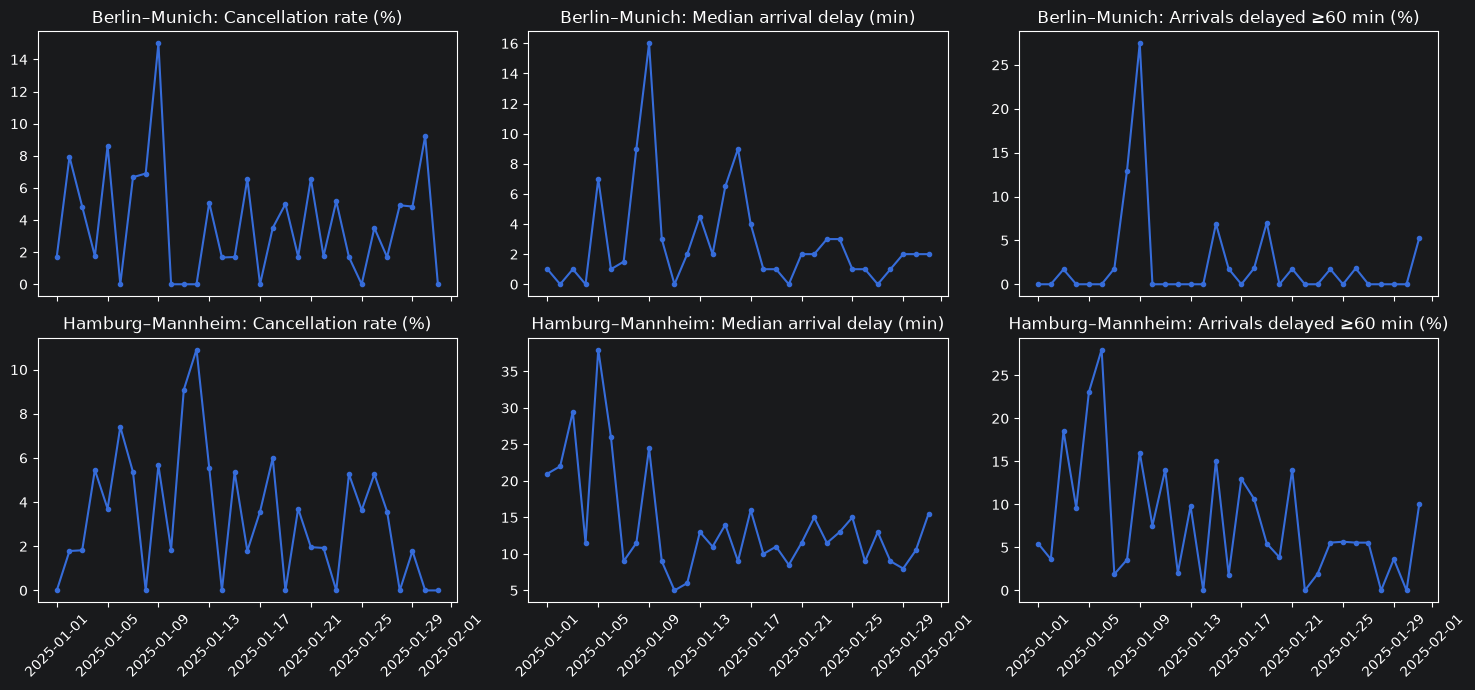

In [16]:
daily = outcome_summary(["corridor", "departure_date"])

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 7),
    sharex="col",
)

metrics = [
    ("cancellation_rate", "Cancellation rate (%)"),
    ("median_delay", "Median arrival delay (min)"),
    ("severe_delay_rate", "Arrivals delayed ≥60 min (%)"),
]

for row, (corridor, group) in enumerate(daily.groupby("corridor")):
    for column, (metric, label) in enumerate(metrics):
        axes[row, column].plot(
            group["departure_date"],
            group[metric],
            marker="o",
            markersize=3,
        )
        axes[row, column].set_title(f"{corridor}: {label}")
        axes[row, column].tick_params(
            axis="x",
            rotation=45,
        )

plt.tight_layout()
plt.show()

In [17]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

corridor_segments["weekday"] = pd.Categorical(
    corridor_segments["weekday"],
    categories=weekday_order,
    ordered=True,
)

weekday_summary = outcome_summary(["corridor", "weekday"])
display(
    weekday_summary.sort_values(["corridor", "weekday"]).round(2)
)

hour_summary = outcome_summary(["corridor", "departure_hour"])

# Suppress particularly small hourly groups.
hour_summary = hour_summary.loc[
    hour_summary["journeys"].ge(20)
]

display(
    hour_summary.sort_values(
        ["corridor", "departure_hour"]
    ).round(2)
)

,corridor,weekday,journeys,cancellations,cancellation_rate,completed_arrivals,median_delay,severe_delays,severe_delay_rate
0,Berlin–Munich,Monday,232,5,2.16,227,1.0,0,0.00
1,Berlin–Munich,Tuesday,242,12,4.96,230,2.0,2,0.87
2,Berlin–Munich,Wednesday,294,10,3.40,284,3.0,11,3.87
3,Berlin–Munich,Thursday,307,27,8.79,280,3.5,15,5.36
4,Berlin–Munich,Friday,296,4,1.35,292,2.0,5,1.71
5,Berlin–Munich,Saturday,222,3,1.35,219,0.0,1,0.46
6,Berlin–Munich,Sunday,231,10,4.33,221,2.0,5,2.26
7,Hamburg–Mannheim,Monday,218,11,5.05,207,13.0,24,11.59
8,Hamburg–Mannheim,Tuesday,216,4,1.85,212,10.0,8,3.77
9,Hamburg–Mannheim,Wednesday,275,5,1.82,270,14.0,15,5.56


,corridor,departure_hour,journeys,cancellations,cancellation_rate,completed_arrivals,median_delay,severe_delays,severe_delay_rate
0,Berlin–Munich,4,26,0,0.00,26,2.0,0,0.00
1,Berlin–Munich,5,106,4,3.77,102,1.5,0,0.00
2,Berlin–Munich,6,98,4,4.08,94,1.0,0,0.00
3,Berlin–Munich,7,125,3,2.40,122,1.0,2,1.64
4,Berlin–Munich,8,193,11,5.70,182,4.0,2,1.10
5,Berlin–Munich,9,94,1,1.06,93,1.0,0,0.00
6,Berlin–Munich,10,96,3,3.12,93,1.0,3,3.23
7,Berlin–Munich,11,126,3,2.38,123,1.0,3,2.44
8,Berlin–Munich,12,129,6,4.65,123,2.0,0,0.00
9,Berlin–Munich,13,96,4,4.17,92,1.0,1,1.09


### Variation over time

Disruption varies substantially between individual days. Berlin–Munich
has its clearest disruption peak on 9 January. Hamburg–Mannheim shows
separate peaks in median delay, severe delays and cancellations on
5, 6 and 12 January.

Berlin–Munich has relatively small median delays across weekdays and
departure hours. Hamburg–Mannheim is less reliable, particularly for
services departing during the afternoon and early evening. Departures
between approximately 14:00 and 18:00 have median destination delays
between 16.5 and 22 minutes.

These patterns are descriptive results from a single month. They are
not sufficient to establish a general weekday or time-of-day effect.

In [18]:
delay_evolution = corridor_segments.loc[
    corridor_segments["departure_delay_min"].notna()
    & corridor_segments["arrival_delay_min"].notna()
].copy()

delay_evolution["delay_change_min"] = (
    delay_evolution["arrival_delay_min"]
    - delay_evolution["departure_delay_min"]
)

delay_evolution["change_class"] = np.select(
    [
        delay_evolution["delay_change_min"].ge(5),
        delay_evolution["delay_change_min"].le(-5),
    ],
    [
        "Gained at least 5 minutes",
        "Recovered at least 5 minutes",
    ],
    default="Changed by less than 5 minutes",
)

evolution_rows = []

for corridor, group in delay_evolution.groupby("corridor"):
    class_counts = group["change_class"].value_counts()

    evolution_rows.append({
        "Corridor": corridor,
        "Journeys": len(group),
        "Median origin delay": group["departure_delay_min"].median(),
        "Median final delay": group["arrival_delay_min"].median(),
        "Median delay change": group["delay_change_min"].median(),
        "Origin/final correlation":
            group[["departure_delay_min", "arrival_delay_min"]]
            .corr()
            .iloc[0, 1],
        "Mean absolute change":
            group["delay_change_min"].abs().mean(),
        "Gained ≥5 min (%)":
            class_counts.get("Gained at least 5 minutes", 0)
            / len(group) * 100,
        "Recovered ≥5 min (%)":
            class_counts.get("Recovered at least 5 minutes", 0)
            / len(group) * 100,
    })

evolution_summary = pd.DataFrame(evolution_rows)
display(evolution_summary.round(2))

,Corridor,Journeys,Median origin delay,Median final delay,Median delay change,Origin/final correlation,Mean absolute change,Gained ≥5 min (%),Recovered ≥5 min (%)
0,Berlin–Munich,1745,1.0,2.0,1.0,0.28,8.49,27.62,8.48
1,Hamburg–Mannheim,1618,1.0,13.0,10.0,0.27,19.45,68.23,4.02


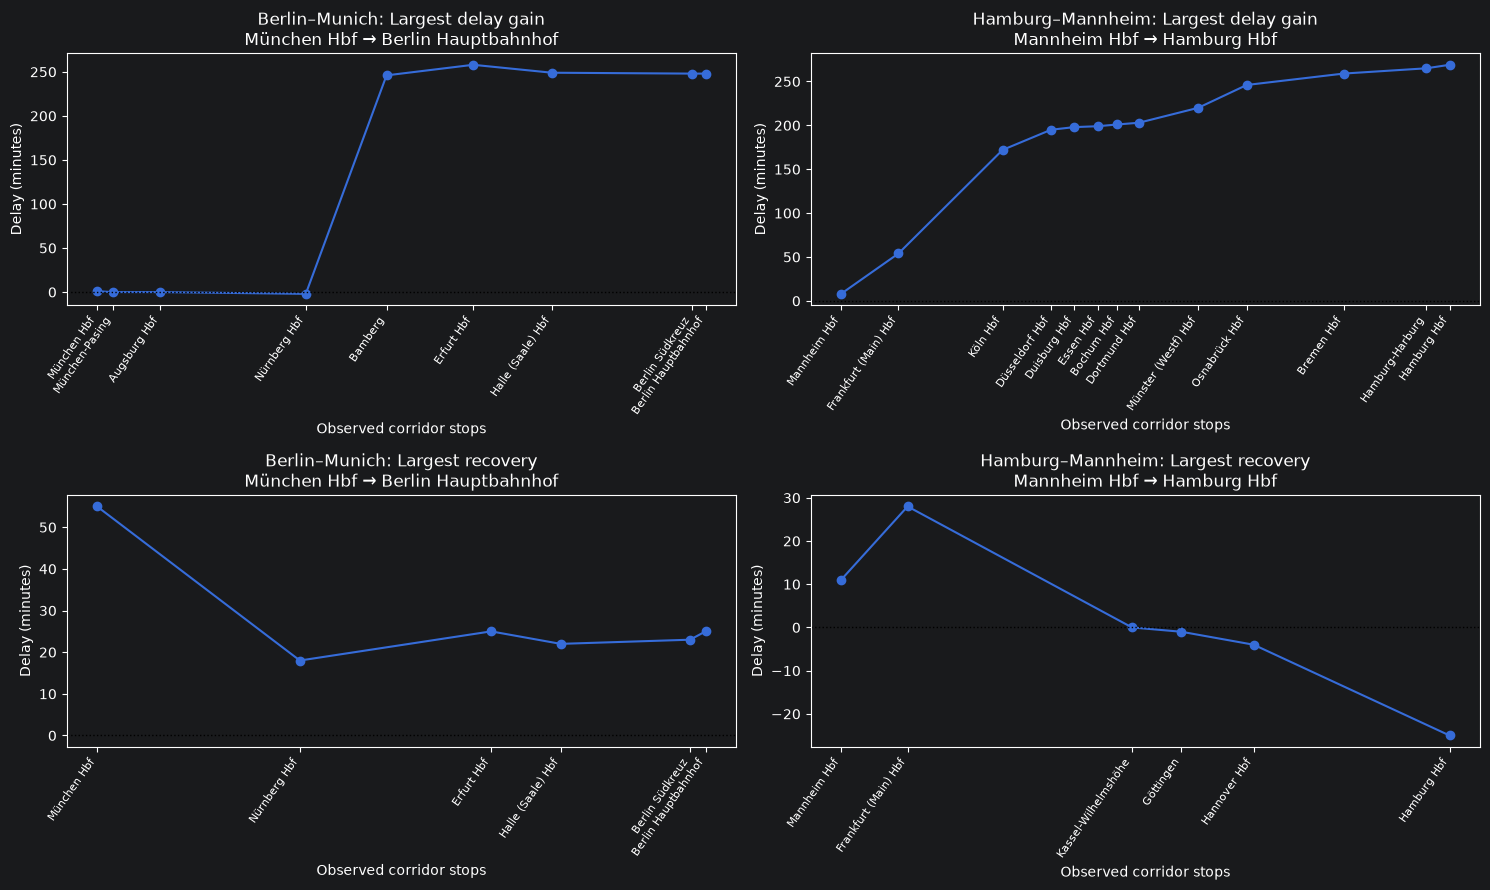

In [19]:
gain_examples = (
    delay_evolution.loc[
        delay_evolution.groupby("corridor")[
            "delay_change_min"
        ].idxmax()
    ]
    .assign(example_type="Largest delay gain")
)

recovery_examples = (
    delay_evolution.loc[
        delay_evolution.groupby("corridor")[
            "delay_change_min"
        ].idxmin()
    ]
    .assign(example_type="Largest recovery")
)

examples = pd.concat(
    [gain_examples, recovery_examples],
    ignore_index=True,
)


def trajectory_points(segment):
    intermediate = stops.loc[
        stops["journey_key"].eq(segment["journey_key"])
        & stops["arrival_planned_time"].gt(
            segment["origin_departure_planned"]
        )
        & stops["arrival_planned_time"].lt(
            segment["destination_arrival_planned"]
        )
        & ~stops["station_name"].isin([
            segment["origin"],
            segment["destination"],
        ])
        & ~stops["arrival_is_canceled"]
    ].copy()

    intermediate["planned_time"] = (
        intermediate["arrival_planned_time"]
    )
    intermediate["delay"] = (
        intermediate["arrival_change_time"]
        - intermediate["arrival_planned_time"]
    ).dt.total_seconds() / 60

    points = pd.DataFrame([
        {
            "station": segment["origin"],
            "planned_time": segment["origin_departure_planned"],
            "delay": segment["departure_delay_min"],
        },
        {
            "station": segment["destination"],
            "planned_time": segment["destination_arrival_planned"],
            "delay": segment["arrival_delay_min"],
        },
    ])

    intermediate = intermediate.rename(
        columns={"station_name": "station"}
    )[["station", "planned_time", "delay"]]

    points = (
        pd.concat([points, intermediate], ignore_index=True)
        .dropna(subset=["delay"])
        .sort_values("planned_time")
    )

    total_time = (
        segment["destination_arrival_planned"]
        - segment["origin_departure_planned"]
    ).total_seconds()

    points["progress"] = (
        points["planned_time"]
        - segment["origin_departure_planned"]
    ).dt.total_seconds() / total_time * 100

    return points


fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, (_, example) in zip(axes.flat, examples.iterrows()):
    points = trajectory_points(example)

    ax.plot(points["progress"], points["delay"], marker="o")
    ax.axhline(0, color="black", linestyle=":", linewidth=1)

    ax.set_xticks(points["progress"])
    ax.set_xticklabels(
        points["station"],
        rotation=55,
        ha="right",
        fontsize=8,
    )

    ax.set_title(
        f"{example['corridor']}: {example['example_type']}\n"
        f"{example['origin']} → {example['destination']}"
    )
    ax.set_ylabel("Delay (minutes)")
    ax.set_xlabel("Observed corridor stops")

plt.tight_layout()
plt.show()

### Delay evolution

Berlin–Munich journeys usually change relatively little between the
corridor origin and destination. The median increase is one minute, and
63.90% change by less than five minutes.

Hamburg–Mannheim behaves differently. Its median journey leaves the
origin one minute late but reaches the corridor endpoint 13 minutes
late. In 68.23% of completed journeys, at least five additional minutes
of delay are accumulated.

The correlation between origin and final delays is modest for both
corridors. This supports using intermediate journey information for
dynamic prediction rather than relying only on the departure delay.

In [20]:
segment_metadata = corridor_segments[[
    "segment_id",
    "journey_key",
    "corridor",
    "origin",
    "destination",
    "origin_departure_planned",
    "destination_arrival_planned",
]]

segment_stops = segment_metadata.merge(
    stops,
    on="journey_key",
    how="left",
)

segment_stops["planned_event_time"] = (
    segment_stops["arrival_planned_time"]
    .fillna(segment_stops["departure_planned_time"])
)

intermediate_stops = segment_stops.loc[
    segment_stops["planned_event_time"].gt(
        segment_stops["origin_departure_planned"]
    )
    & segment_stops["planned_event_time"].lt(
        segment_stops["destination_arrival_planned"]
    )
    & ~segment_stops["station_name"].eq(
        segment_stops["origin"]
    )
    & ~segment_stops["station_name"].eq(
        segment_stops["destination"]
    )
].copy()

intermediate_stops["intermediate_cancel"] = (
    intermediate_stops["arrival_is_canceled"]
    | intermediate_stops["departure_is_canceled"]
)

intermediate_flags = (
    intermediate_stops
    .groupby("segment_id")
    .agg(
        intermediate_cancel=("intermediate_cancel", "any"),
        intermediate_additional=("is_additional_stop", "any"),
        intermediate_replacement=("is_replacement_train", "any"),
    )
    .reset_index()
)

cancellation_patterns = corridor_segments.merge(
    intermediate_flags,
    on="segment_id",
    how="left",
)

flag_columns = [
    "intermediate_cancel",
    "intermediate_additional",
    "intermediate_replacement",
]

cancellation_patterns[flag_columns] = (
    cancellation_patterns[flag_columns].fillna(False)
)

cancellation_patterns["origin_cancel"] = (
    cancellation_patterns["origin_departure_canceled"]
)

cancellation_patterns["destination_cancel"] = (
    cancellation_patterns["destination_arrival_canceled"]
)

cancellation_patterns["endpoint_cancel"] = (
    cancellation_patterns["origin_cancel"]
    | cancellation_patterns["destination_cancel"]
)

cancellation_patterns["any_segment_cancel"] = (
    cancellation_patterns[
        [
            "origin_cancel",
            "intermediate_cancel",
            "destination_cancel",
        ]
    ].any(axis=1)
)

cancellation_patterns["has_additional_stop"] = (
    cancellation_patterns["origin_is_additional"]
    | cancellation_patterns["destination_is_additional"]
    | cancellation_patterns["intermediate_additional"]
)

cancellation_patterns["has_replacement_train"] = (
    cancellation_patterns["origin_is_replacement"]
    | cancellation_patterns["destination_is_replacement"]
    | cancellation_patterns["intermediate_replacement"]
)

In [21]:
pattern_rows = []

for corridor, group in cancellation_patterns.groupby("corridor"):
    row = {
        "Corridor": corridor,
        "Journeys": len(group),
    }

    for column in [
        "origin_cancel",
        "intermediate_cancel",
        "destination_cancel",
        "endpoint_cancel",
        "any_segment_cancel",
        "has_additional_stop",
        "has_replacement_train",
    ]:
        row[f"{column} count"] = group[column].sum()
        row[f"{column} (%)"] = group[column].mean() * 100

    pattern_rows.append(row)

pattern_summary = pd.DataFrame(pattern_rows)
display(pattern_summary.round(2))

,Corridor,Journeys,origin_cancel count,origin_cancel (%),intermediate_cancel count,intermediate_cancel (%),destination_cancel count,destination_cancel (%),endpoint_cancel count,endpoint_cancel (%),any_segment_cancel count,any_segment_cancel (%),has_additional_stop count,has_additional_stop (%),has_replacement_train count,has_replacement_train (%)
0,Berlin–Munich,1824,69,3.78,89,4.88,71,3.89,79,4.33,89,4.88,39,2.14,45,2.47
1,Hamburg–Mannheim,1690,34,2.01,116,6.86,56,3.31,72,4.26,121,7.16,76,4.50,7,0.41


In [22]:
overlap_table = (
    cancellation_patterns
    .groupby("corridor")[
        [
            "origin_cancel",
            "intermediate_cancel",
            "destination_cancel",
        ]
    ]
    .value_counts()
    .to_frame("Journeys")
)

display(overlap_table)

Journeys
corridor         origin_cancel intermediate_cancel destination_cancel          
Berlin–Munich    False         False               False                   1735
                 True          True                True                      61
                 False         True                True                      10
                                                   False                     10
                 True          True                False                      8
Hamburg–Mannheim False         False               False                   1569
                               True                False                     49
                                                   True                      35
                 True          True                True                      18
                                                   False                     14
                 False         False               True                       3
                 True          False               False                      2

### Cancellation patterns

Cancellations frequently affect several stops in the same journey.
Berlin–Munich has an endpoint cancellation rate of 4.33%, while
Hamburg–Mannheim has a similar rate of 4.26%.

Hamburg–Mannheim has more intermediate-stop cancellations: 6.86%,
compared with 4.88% for Berlin–Munich. An intermediate cancellation
does not necessarily prevent travel between the selected endpoints. It
may mean that the train skipped another station while still serving the
passenger's origin and destination.

For this reason, the main passenger-level cancellation outcome should
be defined as cancellation of the origin departure or destination
arrival. “Any segment cancellation” should be retained as a separate
indicator of timetable alteration.

Additional stops and replacement trains are also kept as separate
features. They indicate changed operation but should not automatically
be labelled as cancelled journeys.